# Load Libraries


In [12]:
import os
import random
import numpy as np
import torch


import yfinance as yf
import numpy as np
import torch
import subprocess
import pandas as pd
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler

from momentfm import MOMENTPipeline

In [1]:
SEED = 42

# Python & NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset Class

In [2]:
scaler = MinMaxScaler()

class StockForecastDataset(Dataset):
    def __init__(
        self,
        tickers=None,
        start="2016-01-01",
        end="2025-01-01",
        context_length=512,
        forecast_horizon=192,
        split="train",
        train_ratio=0.7,
        val_ratio=0.1,
    ):
        if tickers is None:
            tickers = ["AAPL"]

        df = yf.download(tickers, start=start, end=end, progress=False)

        # Extract Close prices
        if isinstance(df.columns, pd.MultiIndex):
            prices = df.xs("Close", axis=1, level=0)
        else:
            prices = df["Close"].to_frame()

        # Validate tickers
        missing = set(tickers) - set(prices.columns)
        if missing:
            raise ValueError(f"Missing tickers: {missing}")

        prices = prices[tickers].ffill().bfill()
        series = prices.values.astype(np.float32)

        n = len(series)
        print(n)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        # Prevent leakage
        offset = context_length + forecast_horizon
        train_end -= offset
        val_end -= offset

        train_data = series[:train_end]
        test_data = series[train_end:]

        scaler.fit(series[:train_end])
        train_data = scaler.transform(series[:train_end])
        test_data = scaler.transform(series[train_end:])

        if split == "train":
            self.data = train_data
        elif split == "val":
            self.data = test_data
        # elif split == "test":
        #     self.data = series[val_end:]
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")

        if len(self.data) < context_length + forecast_horizon:
            print(len(self.data))
            raise ValueError(f"Not enough data for split='{split}'")

        self.context_length = context_length
        self.forecast_horizon = forecast_horizon
        self.num_channels = self.data.shape[1]

    def __len__(self):
        return len(self.data) - self.context_length - self.forecast_horizon + 1

    def __getitem__(self, idx):
        x_raw = self.data[idx : idx + self.context_length]
        y_raw = self.data[
            idx + self.context_length :
            idx + self.context_length + self.forecast_horizon
        ]

        mean = x_raw.mean(axis=0, keepdims=True)
        std = x_raw.std(axis=0, keepdims=True) + 1e-5

        x = torch.from_numpy(((x_raw - mean) / std).T).float()
        y = torch.from_numpy(((y_raw - mean) / std).T).float()

        input_mask = torch.ones(self.context_length, dtype=torch.bool)

        return x, y, input_mask


In [3]:

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large", 
    model_kwargs={
        'task_name': 'forecasting',
        'forecast_horizon': 192,
        'context_length':512,
        'head_dropout': 0.1,
        'weight_decay': 0.005,
        'freeze_encoder': True, # Freeze the patch embedding layer
        'freeze_embedder': True, # Freeze the transformer encoder
        'freeze_head': False, # The linear forecasting head must be trained
    },
    # local_files_only=True,  # Whether or not to only look at local files (i.e., do not try to download the model).
)


/rds/general/user/aka225/home/venv/lib64/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
2026-02-15 22:55:14.180595: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/rds/general/user/aka225/home/venv/lib64/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [4]:
model.init()

# Ensure model is on the correct device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model initialized with task: {model.task_name}")

/rds/general/user/aka225/home/venv/lib64/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


Model initialized with task: forecasting


In [5]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")

try:
    # Try to get driver info directly via python
    print(f"Number of GPUs: {torch.cuda.device_count()}")
except Exception as e:
    print(e)

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version PyTorch was built with: 12.8
Number of GPUs: 1


In [6]:
print("Unfrozen parameters:")
for name, param in model.named_parameters():    
    if param.requires_grad:
        print('    ', name)

Unfrozen parameters:
     head.linear.weight
     head.linear.bias


# Model Finetuning

In [8]:
import numpy as np
import torch
import torch.cuda.amp
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm

from momentfm.utils.utils import control_randomness
from momentfm.data.informer_dataset import InformerDataset
from momentfm.utils.forecasting_metrics import get_forecasting_metrics

# Set random seeds for PyTorch, Numpy etc.
control_randomness(seed=13) 


from torch.utils.data import DataLoader

# --- CONFIGURATION ---
BATCH_SIZE = 32
# stock = "^IXIC"
# stock = "GOOGL"
# stock = "AAPL"
stock = "^GSPC"
TICKERS = [stock]
START_DATE = "2013-01-01"  # <--- Changed to 2000 to ensure plenty of data
END_DATE = "2025-01-01"

# --- UPDATED SPLIT RATIOS ---
# Old: Train 0.7 (ok), Val 0.1 (too small), Test 0.2 (marginal)
# New: Train 0.6,      Val 0.2,            Test 0.2
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.2

# 1. Train Dataset
train_dataset = StockForecastDataset(
    tickers=TICKERS, start=START_DATE, end=END_DATE,
    split="train", train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# 2. Validation Dataset
val_dataset = StockForecastDataset(
    tickers=TICKERS, start=START_DATE, end=END_DATE,
    split="val", train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO
)

# # 3. Test Dataset
# test_dataset = StockForecastDataset(
#     tickers=TICKERS, start=START_DATE, end=END_DATE,
#     split="test", train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO
# )


val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# --- DEBUG PRINT ---
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}") # Must be > 0
# print(f"Test samples:  {len(test_dataset)}") # Must be > 0

for i, batch in enumerate(train_loader):
    print(type(batch))
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[2].shape)
    break
 

# l = 1/0
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cur_epoch = 0
max_epoch = 100

# Move the model to the GPU
model = model.to(device)

# Move the loss function to the GPU
criterion = criterion.to(device)

# Enable mixed precision training
scaler = torch.cuda.amp.GradScaler()

# Create a OneCycleLR scheduler
max_lr = 1e-4
total_steps = len(train_loader) * max_epoch
scheduler = OneCycleLR(optimizer, max_lr=max_lr, total_steps=total_steps, pct_start=0.3)

# Gradient clipping value
max_norm = 5.0

while cur_epoch < max_epoch:
    losses = []
    for timeseries, forecast, input_mask in tqdm(train_loader, total=len(train_loader)):
        # Move the data to the GPU
        timeseries = timeseries.float().to(device)
        input_mask = input_mask.to(device)
        forecast = forecast.float().to(device)

        with torch.cuda.amp.autocast():
            output = model(x_enc=timeseries, input_mask=input_mask)
        
        loss = criterion(output.forecast, forecast)

        # Scales the loss for mixed precision training
        scaler.scale(loss).backward()

        # Clip gradients
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        losses.append(loss.item())

    losses = np.array(losses)
    average_loss = np.average(losses)
    print(f"Epoch {cur_epoch}: Train loss: {average_loss:.3f}")

    # Step the learning rate scheduler
    scheduler.step()
    cur_epoch += 1
    
    # Evaluate the model on the test split
    trues, preds, histories, losses = [], [], [], []
    model.eval()
    with torch.no_grad():
        for timeseries, forecast, input_mask in tqdm(val_loader, total=len(val_loader)):
        # Move the data to the GPU
            timeseries = timeseries.float().to(device)
            input_mask = input_mask.to(device)
            forecast = forecast.float().to(device)

            with torch.cuda.amp.autocast():
                output = model(x_enc=timeseries, input_mask=input_mask)
            
            loss = criterion(output.forecast, forecast)                
            losses.append(loss.item())

            trues.append(forecast.detach().cpu().numpy())
            preds.append(output.forecast.detach().cpu().numpy())
            histories.append(timeseries.detach().cpu().numpy())
    
    losses = np.array(losses)
    average_loss = np.average(losses)
    model.train()

    trues = np.concatenate(trues, axis=0)
    preds = np.concatenate(preds, axis=0)
    histories = np.concatenate(histories, axis=0)
    
    metrics = get_forecasting_metrics(y=trues, y_hat=preds, reduction='mean')

    print(f"Epoch {cur_epoch}: Test MSE: {metrics.mse:.3f} | Test MAE: {metrics.mae:.3f}")


3020
3020
Train samples: 1009
Val samples:   605
<class 'list'>
torch.Size([32, 1, 512])
torch.Size([32, 1, 192])
torch.Size([32, 512])


/var/tmp/pbs.1708470.pbs-7/ipykernel_2954588/902136515.py:87: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/var/tmp/pbs.1708470.pbs-7/ipykernel_2954588/902136515.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/rds/general/user/aka225/home/venv/lib64/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/rds/general/user/aka225/home/venv/

Epoch 0: Train loss: 5.023


/var/tmp/pbs.1708470.pbs-7/ipykernel_2954588/902136515.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 19/19 [00:01<00:00, 16.68it/s]


Epoch 1: Test MSE: 3.113 | Test MAE: 1.263


...

Epoch 99: Test MSE: 2.348 | Test MAE: 1.257


100%|██████████| 32/32 [00:02<00:00, 14.97it/s]


Epoch 99: Train loss: 0.702


100%|██████████| 19/19 [00:01<00:00, 16.42it/s]

Epoch 100: Test MSE: 2.377 | Test MAE: 1.267


# Results Visualization

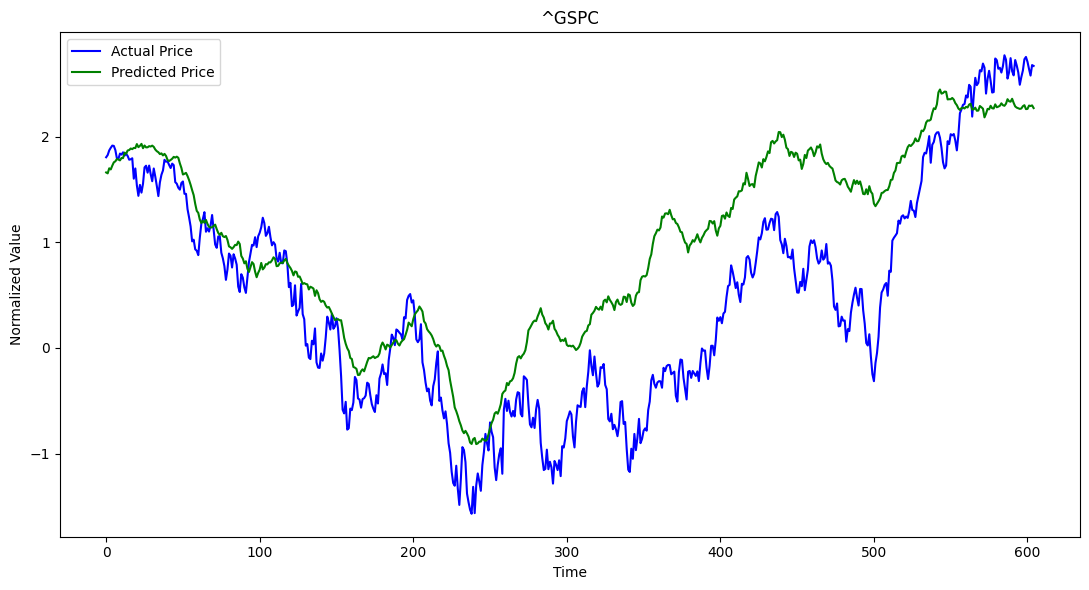

MSE : 0.5618
MAE : 0.6045
RMSE: 0.7496
SMAPE: 91.7657


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# Build continuous series
# =========================
# Use first-step prediction from each window (t+1 forecasting)
y_true_full = trues[:, 0, 0]   # shape: (N,)
y_pred_full = preds[:, 0, 0]   # shape: (N,)


# =========================
# Plot full comparison
# =========================
plt.figure(figsize=(11, 6))

plt.plot(
    y_true_full,
    label="Actual Price",
    color="blue",
    # linewidth=2
)

plt.plot(
    y_pred_full,
    label="Predicted Price",
    color="green",
    # alpha=0.7
)

plt.title(f"{stock}")
plt.xlabel("Time")
plt.ylabel("Normalized Value")
plt.legend()
# plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# =========================
# Metrics (normalized space)
# =========================
mse  = mean_squared_error(y_true_full, y_pred_full)
mae  = mean_absolute_error(y_true_full, y_pred_full)
rmse = np.sqrt(mse)

print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return 100 * np.mean(np.where(denominator == 0, 0, diff / denominator))


print(f"SMAPE: {smape(y_true_full, y_pred_full):.4f}")
